# Comparison of metrics graphs
## *Comparación de gráficas de métricas*

Project workflow / *Flujo de trabajo del proyecto*

| # | EN | ES |
|---|---------|---------|
| 1 | Get the files | Obtener los archivos |
| 2 | Create a metrics dictionary | Crear un diccionario con las métricas |
| 3 | Plot using the dictionary | Graficar en función del diccionario |

In [145]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from glob import glob
import os
import re

## Configuration of Variables and functions
### *Configuración de variables y funciones*

In [ ]:
inputFiles = "/mnt/datos_compartidos/PortafolioProyectos/Vision artificial"

fontTitle = 24
fontLegend = 22
fontAxis = 20

lineWidth = 2.5

In [ ]:
def linealGraphic(graphItems, axisX, axisY, figureTitle = "", figureLoc = 'best', nCol = 3, saveFigure = False, saveName = "lineal.pdf"):  # Define function to plot line graphs from a dict of metric series / Definir función para graficar líneas a partir de un dict de series de métricas

    plt.figure(figsize=(12, 8))  # Create new figure with size 12x8 / Crear nueva figura con tamaño 12x8

    plt.title(figureTitle)  # Set figure title / Establecer título de la figura

    for name, metrics in graphItems.items():  # Iterate over each series (name + metrics dict) / Iterar sobre cada serie (nombre + dict de métricas)
        x = metrics[axisX]  # Extract X-axis data using axisX key / Extraer datos del eje X usando la clave axisX
        y = metrics[axisY]  # Extract Y-axis data using axisY key / Extraer datos del eje Y usando la clave axisY
        plt.plot(x, y, label=f"{name}", linewidth=lineWidth)  # Plot the series with a label and line width / Graficar la serie con etiqueta y ancho de línea

    plt.xlabel(axisX, fontsize=fontTitle)  # Set X-axis label with title font size / Establecer etiqueta del eje X con tamaño de fuente de título
    plt.ylabel(axisY, fontsize=fontTitle)  # Set Y-axis label with title font size / Establecer etiqueta del eje Y con tamaño de fuente de título
    plt.legend(  # Configure legend / Configurar leyenda
        loc=figureLoc,  # Legend location / Ubicación de la leyenda
        fontsize=fontLegend,  # Legend font size / Tamaño de fuente de la leyenda
        ncol=nCol  # Number of columns in legend / Número de columnas en la leyenda
    )
    plt.xticks(fontsize=fontAxis)  # Set X-axis tick font size / Establecer tamaño de fuente de las marcas del eje X
    plt.yticks(fontsize=fontAxis)  # Set Y-axis tick font size / Establecer tamaño de fuente de las marcas del eje Y
    plt.grid(True, alpha=0.3)  # Show grid with 30% opacity / Mostrar cuadrícula con 30% de opacidad
    plt.tight_layout(pad=3.0)  # Adjust layout with padding / Ajustar diseño con relleno
    if saveFigure:  # If saving is enabled / Si guardar está habilitado
        plt.savefig(saveName, dpi=300, bbox_inches='tight')  # Save figure at 300 DPI / Guardar figura a 300 DPI
    plt.show()  # Show the figure / Mostrar la figura

def barGraphic(graphItems, metricCompare, axisXTitle = "", axisYTitle = "", figureColor = 'blue', saveFigure = False, saveName = "bar.pdf"):  # Define function to plot bar chart comparing a metric / Definir función para graficar barras comparando una métrica

    plt.figure(figsize=(12, 8))  # Create new figure with size 12x8 / Crear nueva figura con tamaño 12x8

    names = list(graphItems.keys())  # Get series names from dict keys / Obtener nombres de series desde las claves del dict
    barValue = [graphItems[name][metricCompare] for name in names]  # Extract metric value for each series / Extraer valor de la métrica para cada serie

    bars = plt.bar(names, barValue, color=figureColor, alpha=0.7)  # Draw bar chart with given color and opacity / Dibujar gráfico de barras con color y opacidad dados

    for bar, valor in zip(bars, barValue):  # Iterate over bars and their values / Iterar sobre las barras y sus valores
        height = bar.get_height()  # Get bar height / Obtener altura de la barra
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,  # Place text above each bar / Colocar texto encima de cada barra
                f'{valor:.2f}', ha='center', va='bottom', fontsize=12)  # Text with 2 decimals, centered / Texto con 2 decimales, centrado

    plt.xlabel(axisXTitle, fontsize=fontTitle)  # Set X-axis label with title font size / Establecer etiqueta del eje X con tamaño de fuente de título
    plt.ylabel(axisYTitle, fontsize=fontTitle)  # Set Y-axis label with title font size / Establecer etiqueta del eje Y con tamaño de fuente de título
    plt.xticks(fontsize=fontAxis)  # Set X-axis tick font size / Establecer tamaño de fuente de las marcas del eje X
    plt.yticks(fontsize=fontAxis)  # Set Y-axis tick font size / Establecer tamaño de fuente de las marcas del eje Y
    plt.tight_layout(pad=3.0)  # Adjust layout with padding / Ajustar diseño con relleno
    if saveFigure:  # If saving is enabled / Si guardar está habilitado
        plt.savefig(saveName, dpi=300, bbox_inches='tight')  # Save figure at 300 DPI / Guardar figura a 300 DPI
    plt.show()  # Show the figure / Mostrar la figura

def sortFiles(nameFile):  # Define function to sort filenames naturally / Definir función para ordenar nombres de archivo de forma natural
    def sortTextNumber(text):  # Inner key function for natural sorting / Función interna de clave para ordenamiento natural
        return [int(idx) if idx.isdigit() else idx.lower() for idx in re.split(r'(\d+)', text)]  # Split into text/number chunks, convert digits to int / Dividir en fragmentos texto/número, convertir dígitos a int
    return sorted(nameFile, key=sortTextNumber)  # Return sorted list using natural key / Devolver lista ordenada usando la clave natural

## Code
### *Código*

In [ ]:
files = []  # Initialize empty list / Inicializar lista vacía

files.extend(glob(os.path.join(inputFiles, "*.csv")))  # Add all CSV files found in input folder / Agregar todos los archivos CSV encontrados en la carpeta de entrada

files = sortFiles(files)  # Sort files naturally (numbers in order) / Ordenar archivos de forma natural (números en orden)

print(files)  # Print sorted file list / Imprimir lista ordenada de archivos

['/mnt/datos_compartidos/PortafolioProyectos/Vision artificial/metricas_YOLO5_por_segundo.csv', '/mnt/datos_compartidos/PortafolioProyectos/Vision artificial/metricas_YOLO8_por_segundo.csv', '/mnt/datos_compartidos/PortafolioProyectos/Vision artificial/metricas_YOLO9_por_segundo.csv', '/mnt/datos_compartidos/PortafolioProyectos/Vision artificial/metricas_YOLO11_por_segundo.csv', '/mnt/datos_compartidos/PortafolioProyectos/Vision artificial/metricas_YOLO12_por_segundo.csv']


In [ ]:
metricsItems = {}  # Initialize dict to store metrics per item / Inicializar dict para almacenar métricas por elemento

for file in files:  # Iterate over each CSV file / Iterar sobre cada archivo CSV
    df = pd.read_csv(file)  # Read CSV into DataFrame / Leer CSV en DataFrame
    headers = list(df.columns)  # Get column names / Obtener nombres de columnas

    nameNoneExt = Path(file).stem  # Get filename without extension / Obtener nombre de archivo sin extensión
    name = nameNoneExt.split("_")[1]  # Extract name after first underscore / Extraer nombre después del primer guion bajo

    metrics = {}  # Initialize dict for metrics of this item / Inicializar dict para métricas de este elemento
    for header in headers:  # Iterate over each column / Iterar sobre cada columna
        metrics[header] = df[header].tolist()  # Convert column to list and store / Convertir columna a lista y almacenar
    metricsItems[name] = metrics  # Store metrics dict under item name / Almacenar dict de métricas bajo el nombre del elemento

print(len(metricsItems))  # Print number of items processed / Imprimir número de elementos procesados

5


In [ ]:
averageItems = {}  # Initialize dict for average metrics per item / Inicializar dict para métricas promedio por elemento

for name, metrics in metricsItems.items():  # Iterate over each item's metrics / Iterar sobre las métricas de cada elemento

    average = {}  # Initialize dict for averages / Inicializar dict para promedios
    for metric in metrics:  # Iterate over each metric / Iterar sobre cada métrica
        average[metric] = np.mean(metrics[metric])  # Compute mean of metric values / Calcular media de los valores de la métrica
    averageItems[name] = average  # Store averages under item name / Almacenar promedios bajo el nombre del elemento

print(averageItems)  # Print dictionary of averages / Imprimir diccionario de promedios

{'YOLO5': {'segundo': np.float64(30.0), 'fps': np.float64(5.466451117836507), 'latencia': np.float64(182.95440126637942), 'ram_uso': np.float64(374.25448258196724), 'cpu_uso': np.float64(86.17213114754097), 'objetos_detectados': np.float64(7.295081967213115)}, 'YOLO8': {'segundo': np.float64(30.0), 'fps': np.float64(5.061556603902894), 'latencia': np.float64(198.26388749919954), 'ram_uso': np.float64(408.9212346311475), 'cpu_uso': np.float64(89.01967213114756), 'objetos_detectados': np.float64(7.131147540983607)}, 'YOLO9': {'segundo': np.float64(30.0), 'fps': np.float64(4.409203291726391), 'latencia': np.float64(226.83641167937733), 'ram_uso': np.float64(405.2373206967213), 'cpu_uso': np.float64(89.37540983606559), 'objetos_detectados': np.float64(7.098360655737705)}, 'YOLO11': {'segundo': np.float64(30.0), 'fps': np.float64(5.048863044931868), 'latencia': np.float64(201.2494822017482), 'ram_uso': np.float64(385.08965163934425), 'cpu_uso': np.float64(87.84754098360654), 'objetos_detect

## Graphics
### *Gráficos*

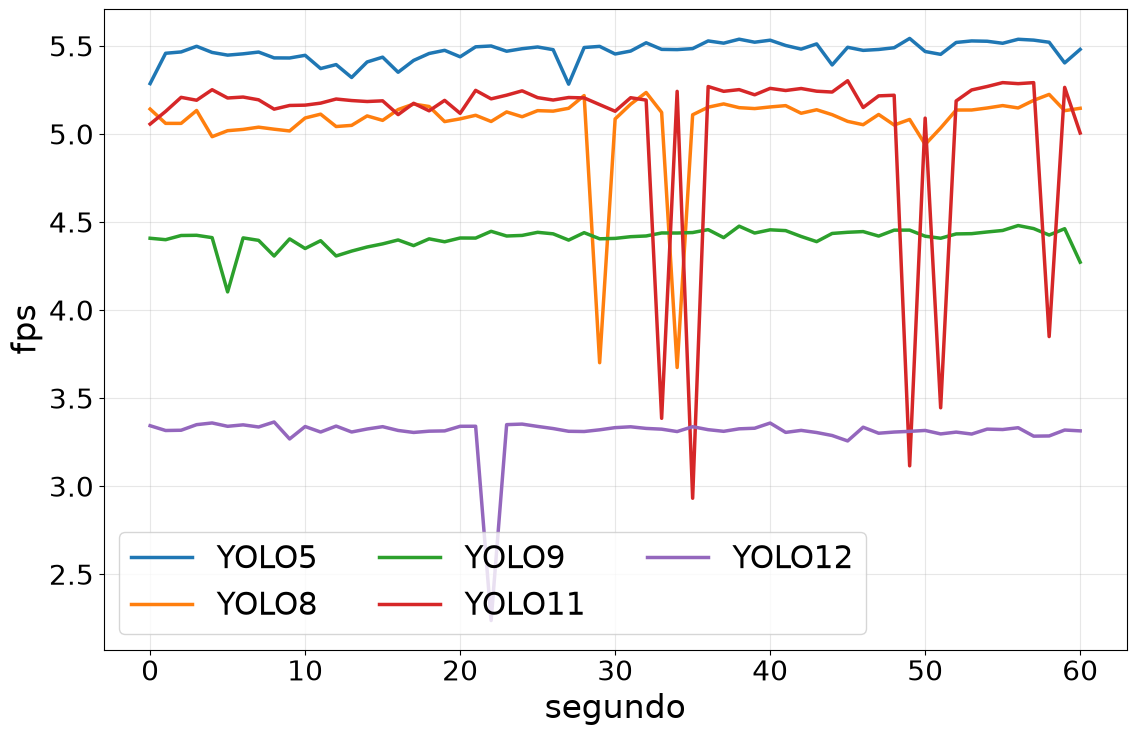

In [ ]:
linealGraphic(metricsItems, axisX='segundo', axisY='fps') # Plot line graph / Graficar líneas

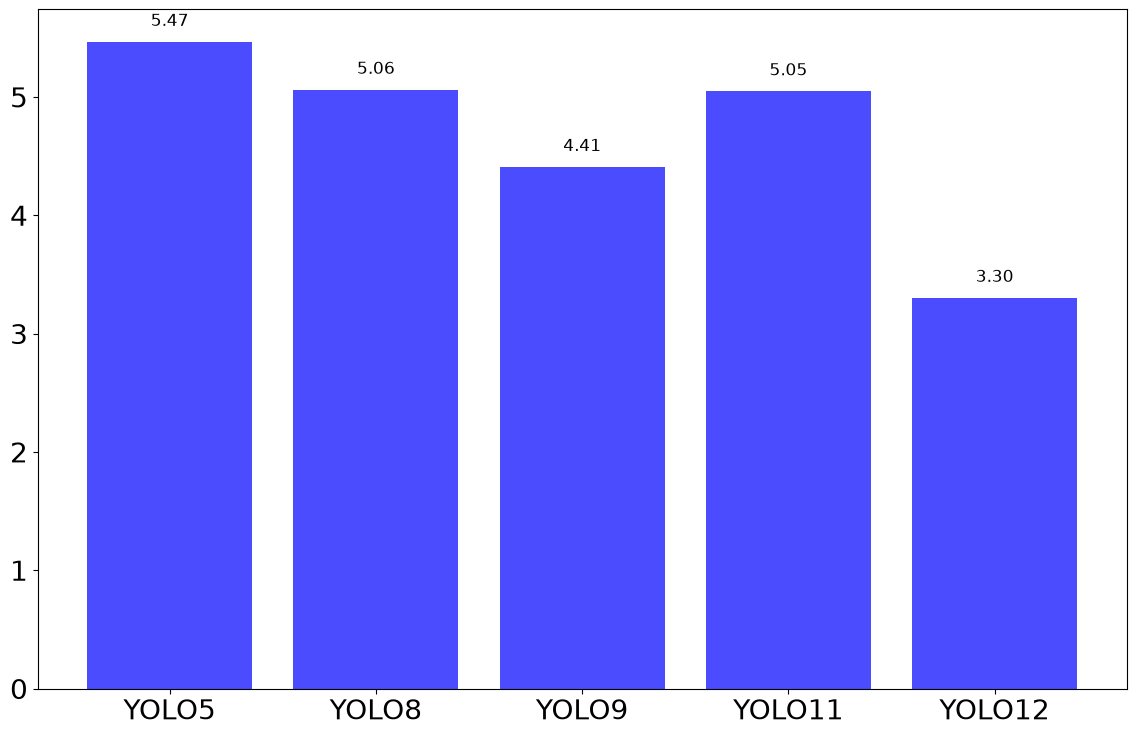

In [ ]:
barGraphic(averageItems, 'fps') # Plot bar chart comparing an average / Graficar barras comparando un promedio

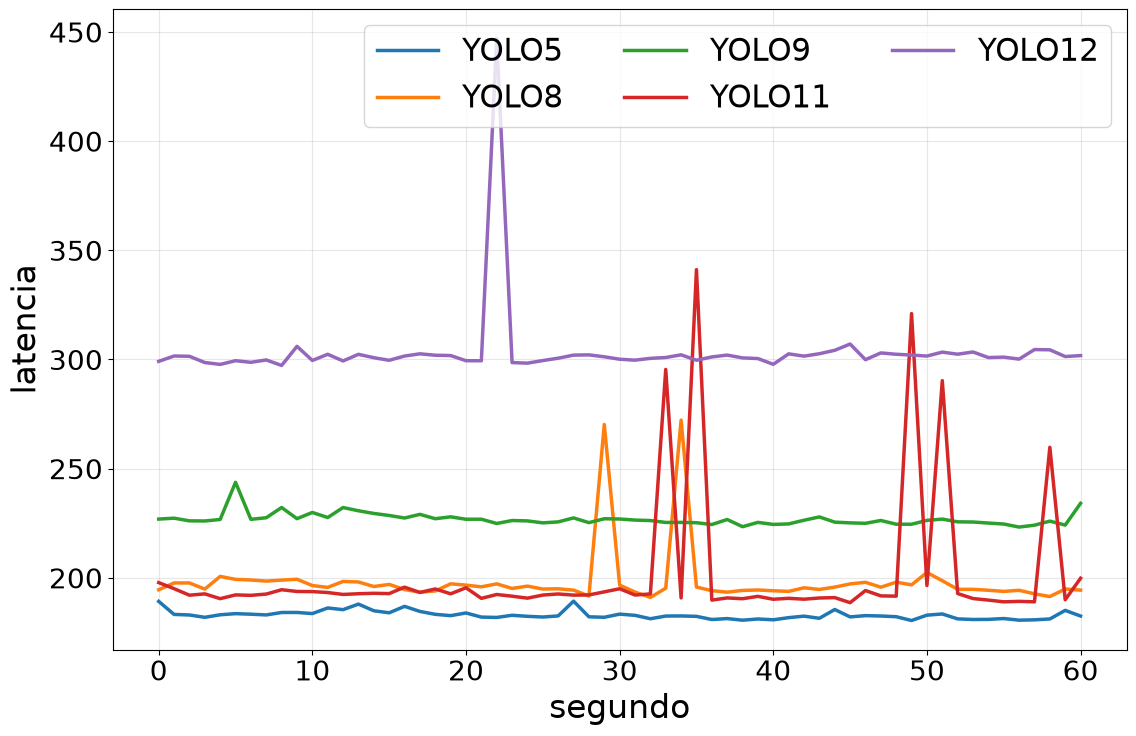

In [ ]:
linealGraphic(metricsItems, axisX='segundo', axisY='latencia') # Plot line graph / Graficar líneas

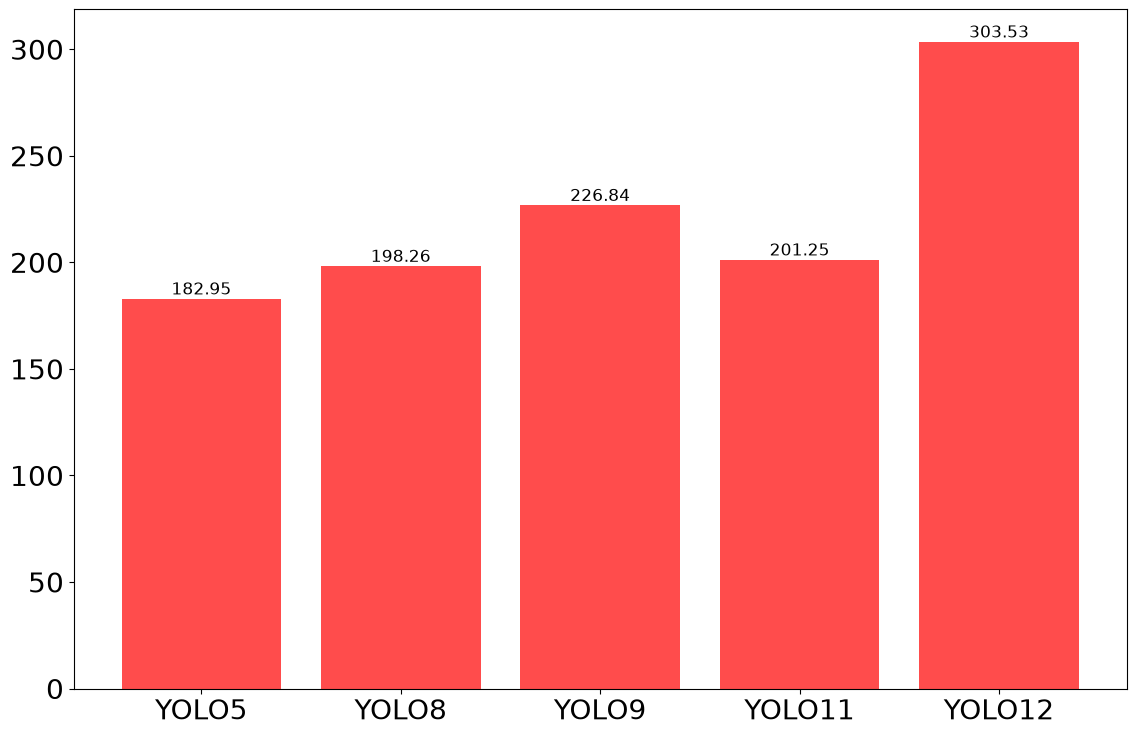

In [ ]:
barGraphic(averageItems, 'latencia', figureColor='red') # Plot bar chart comparing an average / Graficar barras comparando un promedio

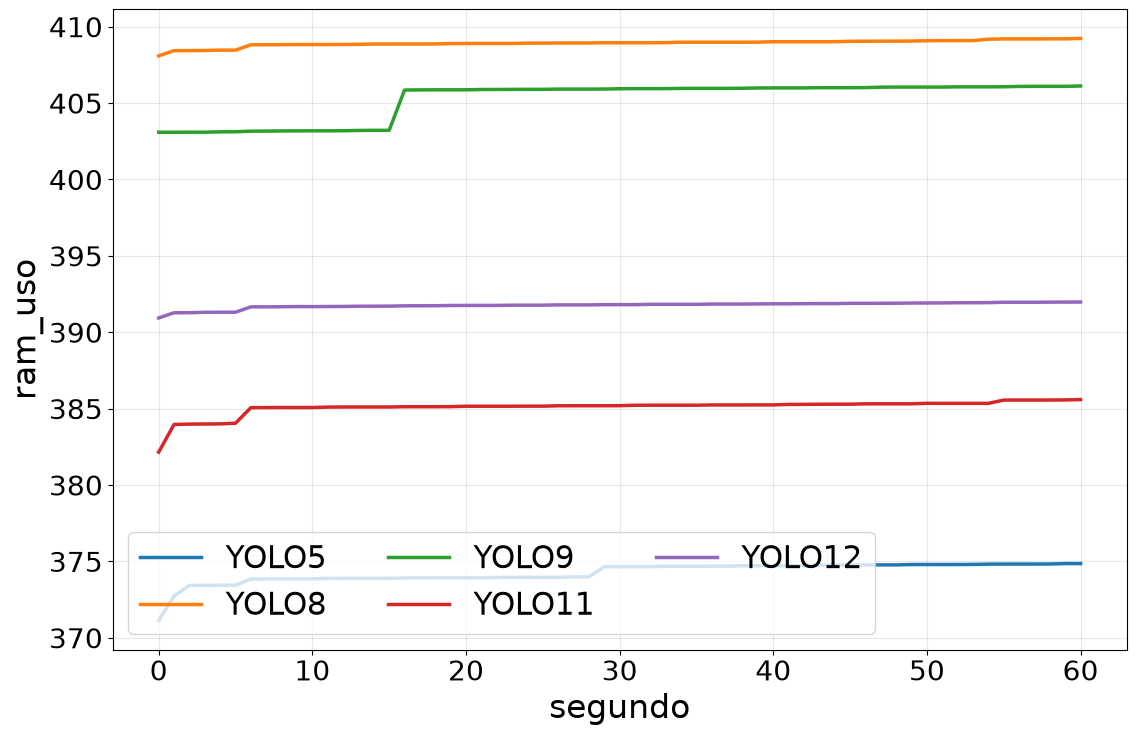

In [ ]:
linealGraphic(metricsItems, axisX='segundo', axisY='ram_uso') # Plot line graph / Graficar líneas

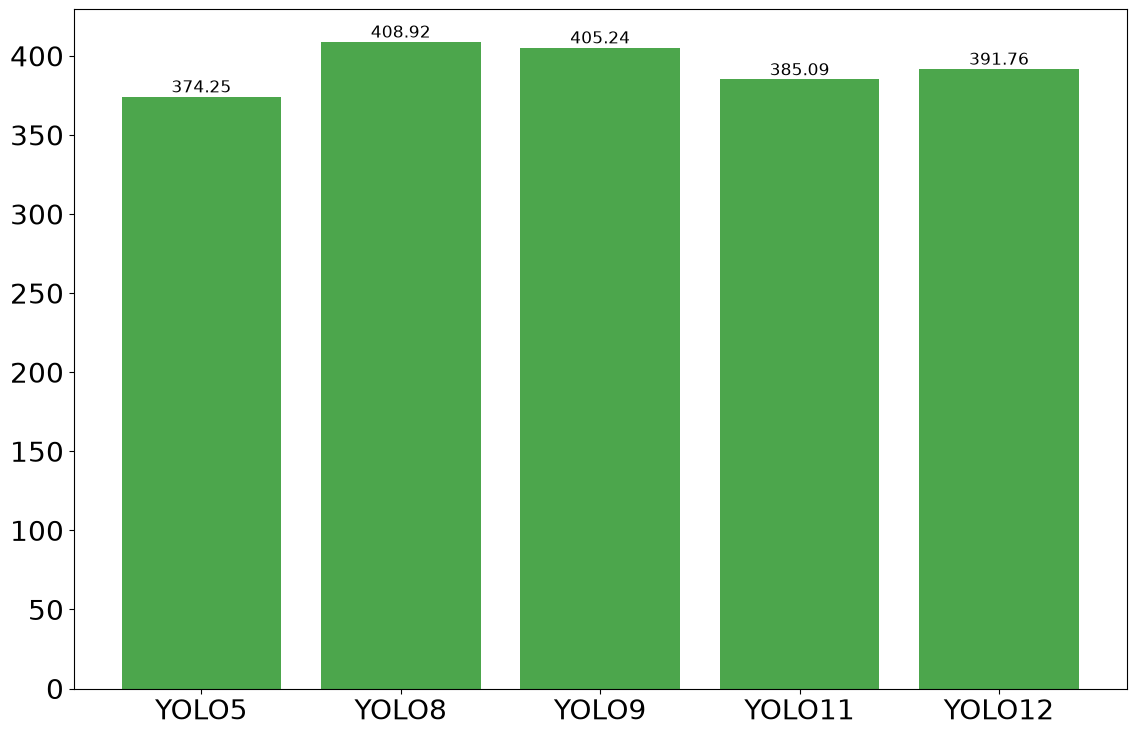

In [ ]:
barGraphic(averageItems, 'ram_uso', figureColor='green') # Plot bar chart comparing an average / Graficar barras comparando un promedio

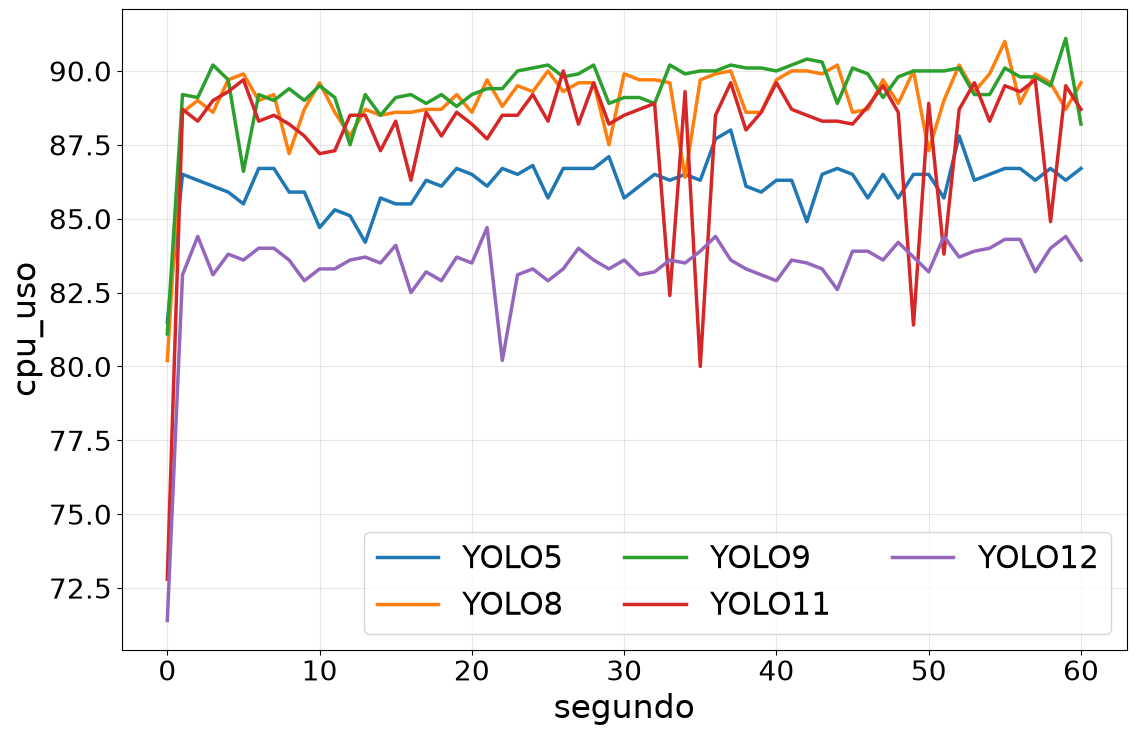

In [ ]:
linealGraphic(metricsItems, axisX='segundo', axisY='cpu_uso') # Plot line graph / Graficar líneas

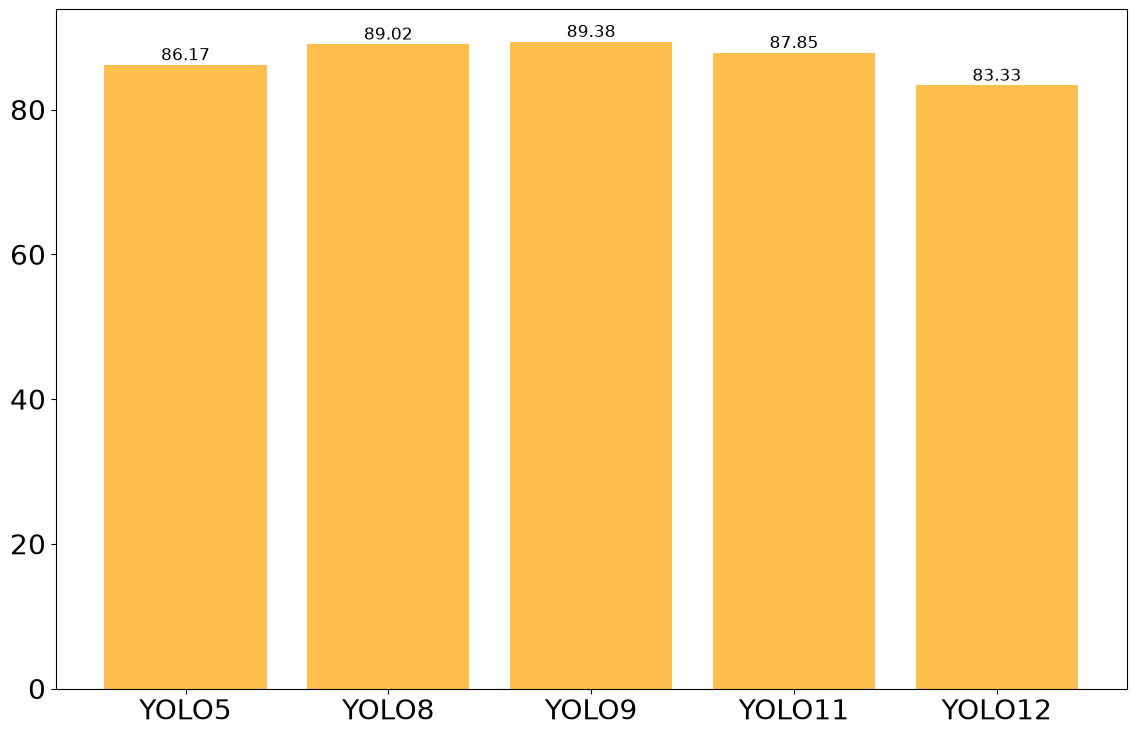

In [ ]:
barGraphic(averageItems, 'cpu_uso', figureColor='orange') # Plot bar chart comparing an average / Graficar barras comparando un promedio